In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  136.80009024813492


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.80009024813492
calculating stable deltas...
Gamma_ii for m1: 22240.72151069398
Gamma_ii for m1: 22240.721510158546
Gamma_ii for m1: 22240.721510652977
Gamma_ii for m1: 22240.7215097721
Gamma_ii for m1: 22240.721508690618
Gamma_ii for m1: 22240.721538590584
Gamma_ii for m1: 22240.721477566345
Gamma_ii for m1: 22240.721214136785
Gamma_ii for m1: 22240.72014820061
Gamma_ii for m1: 22240.725148647558
[np.float64(2.4074492484625077e-11), np.float64(2.223086258588309e-11), np.float64(3.960655503416585e-11), np.float64(4.8626127055077683e-11), np.float64(1.3443793038367605e-09), np.float64(2.7438066133400183e-09), np.float64(1.1844470202773634e-08), np.float64(4.792723297250166e-08),

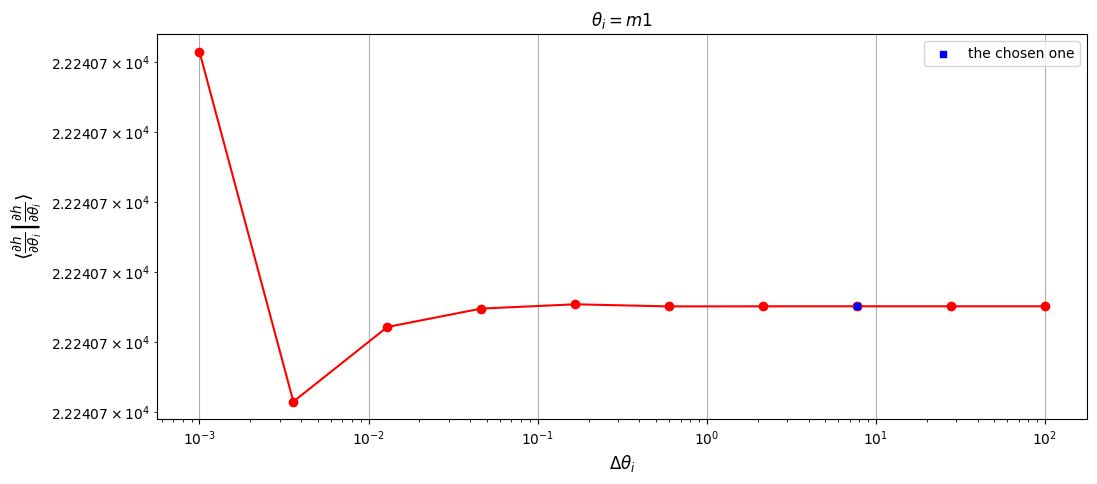

Gamma_ii for m2: 14181547972287.176
Gamma_ii for m2: 14181547971654.309
Gamma_ii for m2: 14181547974033.13
Gamma_ii for m2: 14181547964453.254
Gamma_ii for m2: 14181547985079.852
Gamma_ii for m2: 14181547970641.22
Gamma_ii for m2: 14181547948790.28
Gamma_ii for m2: 14181549043904.73
Gamma_ii for m2: 14181543864114.133
Gamma_ii for m2: 14181559104117.057
[np.float64(4.4626100674267555e-11), np.float64(1.6774066342973983e-10), np.float64(6.75517015288982e-10), np.float64(1.4544672893220731e-09), np.float64(1.0181279849890855e-09), np.float64(1.5408008692107506e-09), np.float64(7.722107421280316e-08), np.float64(3.652487096812863e-07), np.float64(1.0746352225407847e-06)]
0


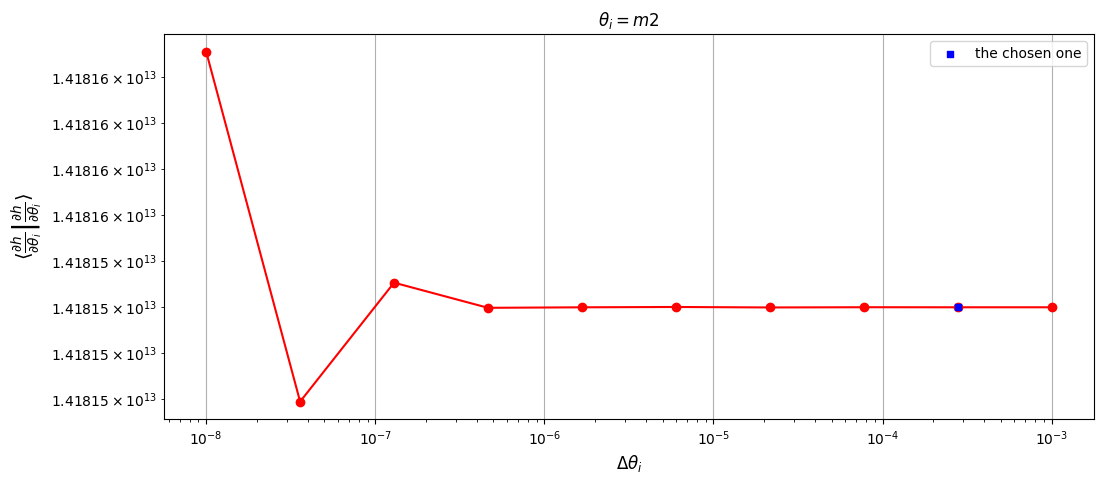

Gamma_ii for a: 1815068494978566.0
Gamma_ii for a: 1815068595031087.0
Gamma_ii for a: 1815068923336297.5
Gamma_ii for a: 1815065049201619.8
Gamma_ii for a: 1815088661907212.8
Gamma_ii for a: 1815051415267730.0
Gamma_ii for a: 1815202669447912.2
Gamma_ii for a: 1814909725370773.5
Gamma_ii for a: 1816653047456067.2
Gamma_ii for a: 1821386685535514.8
[np.float64(5.5123272626666974e-08), np.float64(1.80877544802287e-07), np.float64(2.1344329667160353e-06), np.float64(1.3009119658203827e-05), np.float64(2.0520983135486504e-05), np.float64(8.332633194521109e-05), np.float64(0.00016140972360424347), np.float64(0.0009596340301385531), np.float64(0.0025989198872702532)]
0


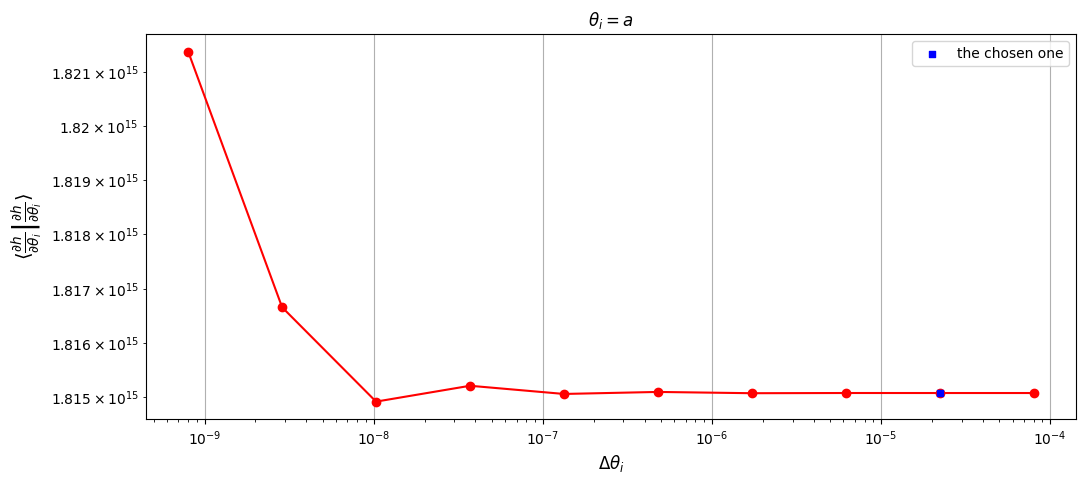

Gamma_ii for p0: 1172377805715645.2
Gamma_ii for p0: 1172377821846246.2
Gamma_ii for p0: 1172377859707287.2
Gamma_ii for p0: 1172378209719792.0
Gamma_ii for p0: 1172376289278271.0
Gamma_ii for p0: 1172380067892086.0
Gamma_ii for p0: 1172379451509869.8
Gamma_ii for p0: 1172404676064853.0
Gamma_ii for p0: 1172403261131592.8
Gamma_ii for p0: 1171556852506226.5
[np.float64(1.3758875935231978e-08), np.float64(3.229423064117991e-08), np.float64(2.985491387064042e-07), np.float64(1.6380760499534214e-06), np.float64(3.2230280251982326e-06), np.float64(5.25753172708871e-07), np.float64(2.1515228912183794e-05), np.float64(1.2068656810834179e-06), np.float64(0.0007224648326332517)]
0


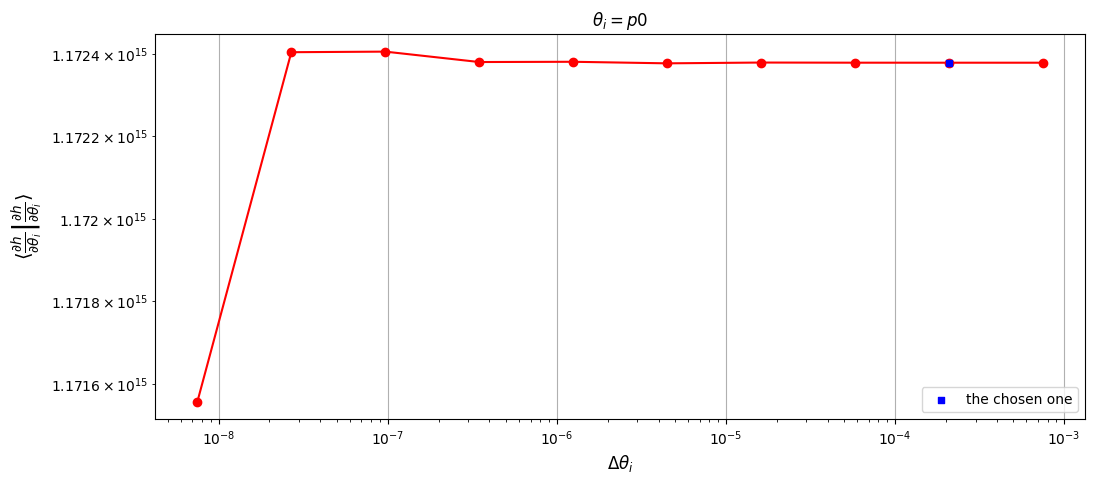

Gamma_ii for e0: 3816612863733878.0
Gamma_ii for e0: 3816613145112865.5
Gamma_ii for e0: 3816610244016562.0
Gamma_ii for e0: 3816600680985632.5
Gamma_ii for e0: 3816632513713348.0
Gamma_ii for e0: 3816570811170121.0
Gamma_ii for e0: 3816194432722876.0
Gamma_ii for e0: 3817413950844936.5
Gamma_ii for e0: 3813514580956628.5
Gamma_ii for e0: 3808975672493094.5
[np.float64(7.37247860345246e-08), np.float64(7.601238056854649e-07), np.float64(2.50564094303687e-06), np.float64(8.340527310691676e-06), np.float64(1.616701124643424e-05), np.float64(9.862664334334031e-05), np.float64(0.0003194618497662731), np.float64(0.001022513433613209), np.float64(0.001191634931226311)]
0


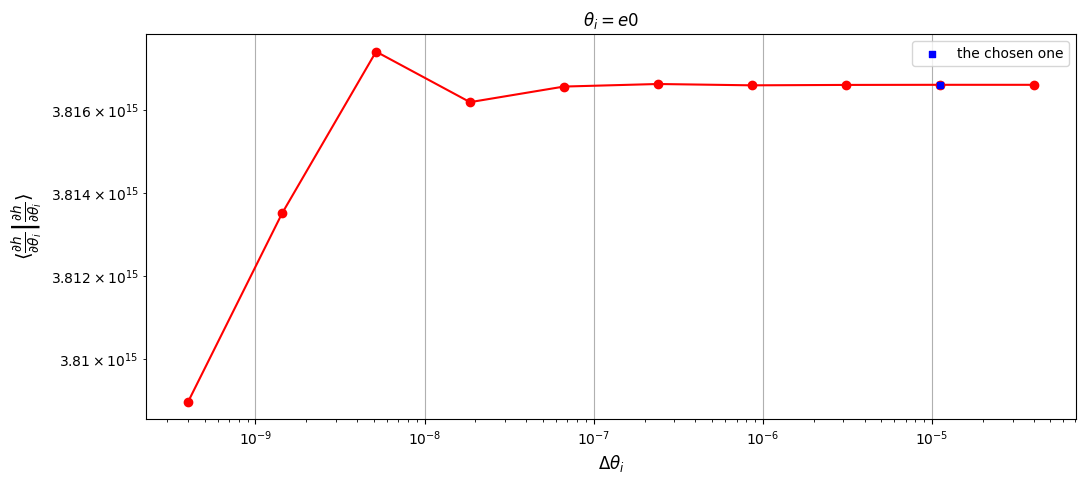

Gamma_ii for qS: 57465.02985506446
Gamma_ii for qS: 57465.02995124751
Gamma_ii for qS: 57465.02995125042
Gamma_ii for qS: 57465.02995125174
Gamma_ii for qS: 57465.029951242665
Gamma_ii for qS: 57465.029951235316
Gamma_ii for qS: 57465.029951125405
Gamma_ii for qS: 57465.0299512895
Gamma_ii for qS: 57465.02995234016
Gamma_ii for qS: 57465.02995336764
[np.float64(1.6737666719892084e-09), np.float64(5.064615903171632e-14), np.float64(2.2917386961851108e-14), np.float64(1.5788940078139695e-13), np.float64(1.2788155155511732e-13), np.float64(1.912652195836928e-12), np.float64(2.8555570616038034e-12), np.float64(1.828351664089803e-11), np.float64(1.7879993368500788e-11)]
2


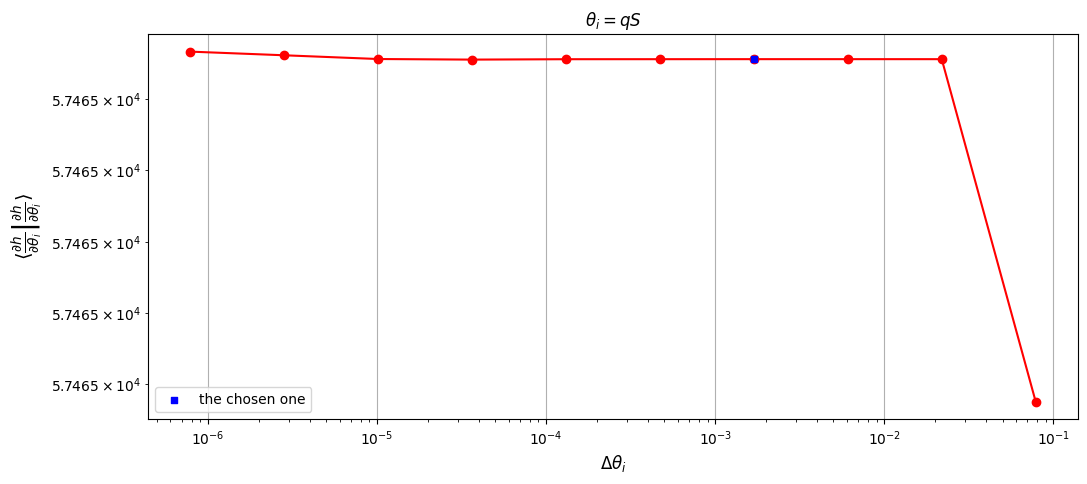

Gamma_ii for phiS: 1108978.3081460032
Gamma_ii for phiS: 1108978.3081097435
Gamma_ii for phiS: 1108978.3081097421
Gamma_ii for phiS: 1108978.3081097421
Gamma_ii for phiS: 1108978.3081097421
Gamma_ii for phiS: 1108978.3081097417
Gamma_ii for phiS: 1108978.3081097438
Gamma_ii for phiS: 1108978.3081097458
Gamma_ii for phiS: 1108978.3081096946
Gamma_ii for phiS: 1108978.3081097482
[np.float64(3.2696444279957465e-11), np.float64(1.2597035052059604e-15), np.float64(0.0), np.float64(0.0), np.float64(4.19901168401987e-16), np.float64(1.889555257808938e-15), np.float64(1.8895552578089344e-15), np.float64(4.618912852422053e-14), np.float64(4.828863436622822e-14)]
2


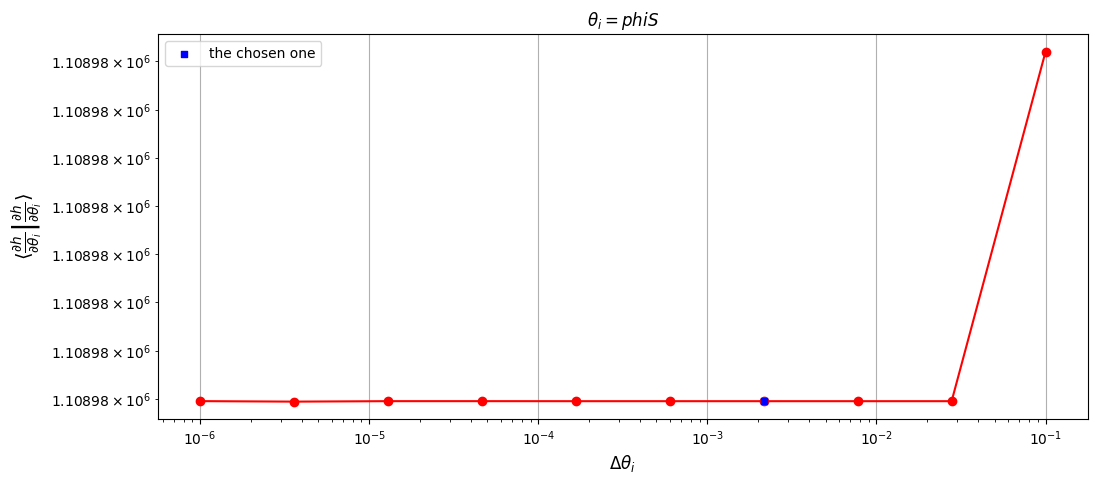

stable deltas: {'m1': 7.742636826811269, 'm2': 0.0002782559402207126, 'a': 2.2260475217657015e-05, 'p0': 0.00020869195516553445, 'e0': 1.1130237608828506e-05, 'qS': 0.0016920890487107918, 'phiS': 0.002154434690031882, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 141.07438850402832 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 15.048848390579224 seconds


In [5]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [33]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])

In [34]:
chi2=0
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)
waveform_true

[0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


array([[ 7.59702251e-22,  6.60831832e-22,  5.20017131e-22, ...,
        -7.08050729e-22, -4.50889192e-22, -1.48300466e-22],
       [-2.23474599e-22, -4.11084661e-22, -5.56564534e-22, ...,
         5.16737452e-22,  7.26660081e-22,  8.20565965e-22]],
      shape=(2, 3155815))

In [35]:
def inner_prod_without_phase(a, b, PSD, dt, window=None, fmin=None, fmax=None, use_gpu=False):

    if use_gpu:
        xp = cp
    else:
        xp = np

    # print("fmin: {}, fmax: {}".format(fmin, fmax))

    # frequency cutoff mask
    if (fmin != None) or (fmax != None):

        length = len(a[0])
        freq = xp.fft.rfftfreq(length) / dt

        if use_gpu:
            freq = freq.get()  # convert to numpy

        if fmin != None:
            mask_min = freq > fmin

        if fmax != None:
            mask_max = freq < fmax

        if (fmin != None) and (fmax == None):
            freq_mask = mask_min
        elif (fmin == None) and (fmax != None):
            freq_mask = mask_max
        else:
            freq_mask = xp.logical_and(mask_min, mask_max)

    else:
        length = len(a[0])
        
        freq = xp.fft.rfftfreq(length) / dt

        freq_mask = np.full(len(freq), True, dtype=bool)

    freq_mask = freq_mask[1:]  # skip the first element corresponding to f = 0.0

    a = xp.atleast_2d(a)
    b = xp.atleast_2d(b)
    PSD = xp.atleast_2d(
        xp.asarray(PSD)
    )  # handle passing the same PSD for multiple channels

    N = a.shape[1]

    df = (N * dt) ** -1

    if window is not None:
        window = xp.atleast_2d(xp.asarray(window))
        a_in = a * window
        b_in = b * window
    else:
        a_in, b_in = a, b

    if xp.iscomplexobj(a_in):
        a_fft_plus = (dt * xp.fft.rfft(a_in.real, axis=-1)[:, 1:])[:, freq_mask]
        a_fft_cross = (dt * xp.fft.rfft(a_in.imag, axis=-1)[:, 1:])[:, freq_mask]

        b_fft_plus = (dt * xp.fft.rfft(b_in.real, axis=-1)[:, 1:])[:, freq_mask]
        b_fft_cross = (dt * xp.fft.rfft(b_in.imag, axis=-1)[:, 1:])[:, freq_mask]

        inner_prod = (
            4
            * df
            * (
                xp.abs(a_fft_plus.conj() * b_fft_plus + a_fft_cross * b_fft_cross.conj()
                / PSD[:, freq_mask])
            ).sum()
        )

    else:
        a_fft = (dt * xp.fft.rfft(a_in, axis=-1)[:, 1:])[:, freq_mask]
        b_fft = (dt * xp.fft.rfft(b_in, axis=-1)[:, 1:])[:, freq_mask]

        # Compute inner products over given channels
        inner_prod = 4 * df * xp.abs(((a_fft.conj() * b_fft)) / PSD[:, freq_mask]).sum()

    if use_gpu:
        inner_prod = inner_prod.get()

    return inner_prod


In [36]:
chi2=0
deviation_included=False
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args, dt=dt, T=T,use_gpu=use_gpu))

    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    return -0.5 * diff_inner * 10

def loglike_calc_snr(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args, dt=dt, T=T))
    diff_inner=inner_prod_without_phase(waveform_temp,waveform_true,PSD,dt,use_gpu=use_gpu)/np.sqrt(inner_prod_without_phase(waveform_temp,waveform_temp,PSD,dt,use_gpu=use_gpu))
    return -0.5 * diff_inner 


In [37]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_ = params[i]
        m1_ = np.exp(logm1_)
        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_)
        log_likes[i] = loglike 
    return log_likes

n=6
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]


def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]


    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])

    
    return u

In [38]:
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]

ranges=[logm1lim, m2lim, alim, p0lim, e0lim, qSlim, phiSlim, Phi_phi0lim, Phi_r0lim]
ranges

[[np.float64(13.815421502314646), np.float64(13.815599613613902)],
 [np.float64(9.999454930808135), np.float64(10.000545069191865)],
 [np.float64(0.799939534708879), np.float64(0.8000604652911211)],
 [np.float64(7.499632562924762), np.float64(7.500367437075238)],
 [np.float64(0.39997968951239726), np.float64(0.4000203104876028)],
 [np.float64(0.7037649382516584), np.float64(0.8670313885432381)],
 [np.float64(0.8967566846670224), np.float64(1.1032433153329775)],
 [np.float64(0.47992930667997546), np.float64(1.3200706933200246)],
 [np.float64(0.29996396963091154), np.float64(0.5000360303690885)]]

In [40]:
# def main():
    
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 9
n_seed = 100  # Number of initial processes
init_cov_list = [np.eye(ndim) * 1e-10] * n_seed
savepath = 'paris_1PA_vs_0PA_3'  # Directory to save results

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")
# sampler.prepare_lhs_samples(lhs_num=int(5e4), batch_size=50)
# x = np.linspace(0.49999, 0.50001, 2000)

# # Generate 99 random points in 11D
# external_lhs_points = np.random.choice(x, size=(99, 11))

# # Add the "true point" [0.5, 0.5, ..., 0.5] as the 100th point
# external_lhs_points = np.vstack([external_lhs_points, [0.5]*11])

#best value got so far
true_point = np.array([0.67939379, 0.82938011, 0.74931654, 0.33684298, 0.27179269, 0.51889631,
 0.53730409, 0.6137629,  0.26045073])
# Generate 99 points around it with tiny Gaussian noise ~1e-10
scatter = 1.0e-7
points = true_point + np.random.randn(99, 9) * scatter
# Add the original point as the 100th row
external_lhs_points = np.vstack([points, true_point])
print("Shape of points array:", external_lhs_points.shape)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external_lhs_log_densities", external_lhs_log_densities)


# external_lhs_points = np.vstack(external_lhs_points)
# external_lhs_log_densities = np.concatenate(external_lhs_log_densities)

sampler.run_sampling(
            num_iterations=int(5e4),
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.01
        )
#except Exception as exc:
 #       print(f"[WARN] PARIS sampling failed: {exc}")
    
# Gt results
print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in[0:9]):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")




Problem dimension: 9
Number of processes: 100
Save path: paris_1PA_vs_0PA_3
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...
Shape of points array: (100, 9)
true points in corrrect space [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]
external_lhs_log_densities [-166.15304004 -166.12716119 -166.1310969  -166.13843872 -166.11333013
 -166.17527186 -166.15957035 -166.24965585 -166.13864028 -166.19250562
 -166.2001462  -166.17340152 -166.15411739 -166.11872581 -166.13778326
 -166.12338447 -166.12066836 -166.12513477 -166.20105666 -166.13355832
 -166.12426778 -166.12567463 -166.19400567 -166.15126213 -166.1799978
 -166.1431146  -166.14989829 -166.12587038 -166.1518042  -166.13023127
 -166.22926335 -166.1149877  -166.20112272 -166.14006005 -166.1171054
 -166.18037021 -166.13421755 -166.11219704 -166.19996303 -166.09529398
 -166.13466998 -166.11128922 -166.20844579 -166.17589832 -166

Sampling:   0%|          | 0/49999 [00:00<?, ?it/s]

Sampling interrupted by user


Extracting results...

Results Summary:
Total samples: 29286
Effective sample size: 1.3

True values: [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]
Estimated deviation: [13.81556871 10.00053383  0.80004804  7.49977467  0.39998433  0.78466984
  1.00056143  0.96234993  0.33422898]
Mean deviation: 0.090634

True covariance diagonal: [2.20303020e-10 8.25278955e-09 1.01556984e-10 3.75027790e-09
 1.14587752e-11 1.85110651e-04 2.96088393e-04 4.90164965e-03
 2.77977983e-04]
Estimated covariance diagonal: [3.27714529e-12 1.07061699e-10 1.52969447e-12 5.98563143e-11
 1.54016703e-13 1.59460134e-05 2.80542857e-05 4.73204280e-04
 2.74291952e-05]


In [30]:
best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
print(np.max(external_lhs_log_densities))
print(best_fit_tn)
prior_transform(np.array([best_fit_tn]))

-830.7971843545087
[0.67939379 0.82938011 0.74931654 0.33684298 0.27179269 0.51889631
 0.53730409 0.6137629  0.26045073]


array([[13.81554251, 10.00035907,  0.80003015,  7.4998801 ,  0.39999073,
         0.7884833 ,  1.0077028 ,  0.99557692,  0.35207288]])

# 12.034
## [13.81556871, 10.00053383 , 0.80004804 , 7.49977467,  0.39998433,  0.78466984, 1.00056143 , 0.96234993 , 0.33422898]

#

#

In [42]:
#print(log_density([params_truth_in]))
log_density([[13.81556871, 10.00053383 , 0.80004804 , 7.49977467,  0.39998433,  0.78466984,
  1.00056143 , 0.96234993 , 0.33422898]])


array([-120.34223099])

In [23]:
inverse_prior_transform(np.array([[13.81554251, 10.00035907,  0.80003015,  7.4998801,   0.39999073,  0.7884833,
  1.00770281,  0.99557683,  0.35207287]]))


array([[0.67939365, 0.8293802 , 0.74931659, 0.33684281, 0.27179278,
        0.51889633, 0.53730416, 0.61376279, 0.26045066]])

In [ ]:
import corner

param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim]

# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)

labels = [
    "logm1", "m2", "a", "p0", "e0","qS", "phiS", "Phi_phi0", "Phi_r0",]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=25,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [16]:
ls

SuperKludge_r/
multi_inference_GWs/
packages_for_multi_inference/
paris_runs/
paris_try_100_batch100000_stop0_01_cov_08/
paris_try_100_batch100000_stop0_01_cov_08_resume/
parismc/
run_for_jupyter.sh*
sampler_flags.json


In [16]:
def summarize(sampler: Sampler) -> None:
    print("Sampler State")
    print("-------------")
    print(f"ndim: {sampler.ndim}")
    print(f"n_proc: {sampler.n_seed}")
    print(f"current_iter: {getattr(sampler, 'current_iter', None)}")
    print(f"savepath: {getattr(sampler, 'savepath', '(unset)')}")
    
state_path = 'paris_1PA_vs_0PA/sampler_state.pkl'
if not os.path.isfile(state_path):
    print(f"Sampler state not found at: {state_path}")
    print("Please run the multimodal example first:")
    print("  python examples/multimodal_example.py")
    raise FileExistsError(f"State file not found: {state_path}")


sampler = Sampler.load_state(state_path)

# Optionally, rebind the functions to the wrappers for clarity
# (unpickling may already have set them to these wrappers).
try:
        sampler.log_density_func_original = log_density
        if hasattr(sampler, "prior_transform") and sampler.prior_transform is not None:
            sampler.prior_transform = prior_transform
        # If prior_transform was set, ensure transformed log-density hook is in place
        if getattr(sampler, "prior_transform", None) is not None:
            sampler.log_density_func = sampler.transformed_log_density_func
        else:
            sampler.log_density_func = sampler.log_density_func_original
        print("Rebound functions after loading state.")
except Exception:
        # Keep going even if attributes differ in older states
        pass

print("Loaded state. Summary before resume:")
summarize(sampler)

    # Continue sampling
print("\nResuming sampling...")
sampler.run_sampling(
num_iterations=int(1e4),
        savepath="paris_try_100_batch100000_stop0_01_cov__10",
        print_iter=200,
        stop_dlogZ=0.01,
    )

print("\nResume completed. Summary after resume:")
summarize(sampler)

    # Optional: quick analysis similar to load_sampler_example
try:
        import numpy as np
        samples, weights = sampler.get_samples_with_weights(flatten=True)
        ess = 1.0 / (weights ** 2).sum()
        wmean = (samples * weights[:, None]).sum(axis=0) / weights.sum()
        print("\nQuick analysis")
        print("--------------")
        print(f"Total samples: {len(samples)}")
        print(f"Effective sample size (ESS): {ess:.1f}")
        print(f"Weighted mean (first 5 dims): {wmean[:5]}")
except Exception as e:
        print(f"Analysis skipped: {e}")


Rebound functions after loading state.
Loaded state. Summary before resume:
Sampler State
-------------
ndim: 9
n_proc: 100
current_iter: 4639
savepath: paris_1PA_vs_0PA

Resuming sampling...


Sampling:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/svu/e1583490/scratch/parismc/parismc/sampler.py:508: RuntimeWarning: overflow encountered in exp
  probabilities_list.append(np.exp(self.searched_log_densities_list[j][ind1:ind2] - self.loglike_normalization))
/home/svu/e1583490/scratch/parismc/parismc/sampler.py:605: RuntimeWarning: overflow encountered in exp
  probabilities_list.append(np.exp(self.searched_log_densities_list[j][ind1:ind2] - self.loglike_normalization))
/home/svu/e1583490/scratch/parismc/parismc/sampler.py:612: RuntimeWarning: invalid value encountered in divide
  probabilities_list[j] /= weights_sum
Value error in sampling: probabilities contain NaN


ValueError: probabilities contain NaN

In [ ]:
print(f"Weighted mean (first 5 dims): {wmean[:]}")

In [ ]:
import corner

param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim]

# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)
labels = [
    "logm1", "m2", "a", "p0", "e0",
    "qS", "phiS", "Phi_phi0", "Phi_r0",
    "dev0p", "dev0e"
]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=20,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [ ]:
n=0.01
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
logm_range=np.linspace(logm1lim[0],logm1lim[1],1000)
val_m=[]

for i in logm_range:
    loglike=log_density(np.array([[i, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e]]))
    val_m.append(loglike)


In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=params_truth_in[0],color='red')
plt.xlabel('logm1')
plt.ylabel('loglike')
plt.title('loglike vs logm1 (0.01 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=qS,color='red')
plt.xlabel('qS')
plt.ylabel('loglike')
plt.title('loglike vs qS (1 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=0,color='red')
plt.xlabel('dev_0_p')
plt.ylabel('loglike')
plt.title('loglike vs dev_0_p (1 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=params_truth_in[4],color='red')
plt.xlabel('e0')
plt.ylabel('loglike')
plt.title('loglike vs e0 (1 std)')

In [ ]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')
covariance= np.linalg.inv(fisher_)
fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in[i], color='k', linestyle='-', lw=2, label='True')
    ax.legend(fontsize=10)


plt.tight_layout()
plt.show()


In [ ]:
from stableemrifisher.plot import CovEllipsePlot
import numpy as np
import matplotlib.pyplot as plt

pars_list = params_truth_in
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

# --- build wave_params dict (same as original) ---
wave_params = {param_names[i]: params_truth_in[i] for i in range(len(pars_list))}

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

# --- create subplots grid ---
fig, axs = plt.subplots(len(covariance), len(covariance), figsize=(20,20))

# --- Fisher covariance ellipse corner plot ---
fig, axs = CovEllipsePlot(
    covariance,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs,
    line_kwargs=line_kwargs
)

# === ADD TRUE PARAMETER LINES (existing behavior) ===
for i in range(len(param_names)):
    ax = axs[i, i]
    ax.axvline(params_truth_in[i], color='k', linestyle='-', lw=2, label='True')
    ax.legend(fontsize=10)

# === ADD 99% CONDITIONAL POSTERIOR LINES ON DIAGONAL ===
for i in range(len(param_names)):

    theta = params_truth_in.copy()  # reference conditioning point
    grid = np.linspace(param_ranges[i][0], param_ranges[i][1], 2000)
    logP = []

    for x in grid:
        theta[i] = x
        lp = log_density(np.array([theta]))
        logP.append(lp[0])


    logP = np.array(logP)
    P = np.exp(logP - logP.max())  # unnormalized conditional posterior
    P /= np.trapezoid(P, grid)         # normalize

    # build CDF and extract 0.5% and 99.5% quantiles
    cdf = np.cumsum(P)
    cdf /= cdf[-1]
    low_99  = grid[np.searchsorted(cdf, 0.005)]
    high_99 = grid[np.searchsorted(cdf, 0.995)]

    # plot the 99% lines on the diagonal subplot
    ax = axs[i, i]
    ax.axvline(low_99,  linestyle="--", lw=2, label="0.5% (conditional)")
    ax.axvline(high_99, linestyle="--", lw=2, label="99.5% (conditional)")
    ax.legend(fontsize=9)

    print(f"{param_names[i]:10s} 99% conditional interval → [{low_99:.6f}, {high_99:.6f}]")

plt.tight_layout()
plt.show()
